# Business question: How can movie sales/success be predicted based on the language of reviews, the marketing aspects, and movie production elements?

# Suggested sub questions:
Language of Reviews: Can the sentiment and semantic themes (extracted via Transformer embeddings) from expert and user reviews accurately predict the box office tier of a movie?

Marketing Aspects: To what extent do the number of theaters and "opening weekend" performance correlate with long-term international box office success?

Production Elements: Which production features (Genre, Runtime, Rating, and Studio) are the strongest predictors of a movie’s financial success?

Model Performance: Which model (Baseline, Random Forest, or Neural Network) provides the highest accuracy in predicting movie success using these combined features?

In [ ]:
# Uploading the libraries that we need

import pandas as pd # for data manipulaion
import seaborn as sns # for visualization
import matplotlib.pyplot as plt # for visualization
import numpy as np # for computation
import re # to work with regular expressions


In [3]:
# Importing the datasets that we need to work with

df_sales = pd.read_excel("../Metacritic dataset/sales.xlsx")
df_meta = pd.read_excel("../Metacritic dataset/metaClean43Brightspace.xlsx")
df_user = pd.read_excel("../Metacritic dataset/UserReviews.xlsx")
df_expert = pd.read_excel("../Metacritic dataset/ExpertReviews.xlsx")

In [4]:
# Check our data frames and data types

df_sales.info()
df_meta.info()
df_user.info()
df_expert.info()

# df_sales.tale(10) # just to check 
# df_sales.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30612 entries, 0 to 30611
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      30612 non-null  int64  
 1   release_date              30612 non-null  object 
 2   title                     30604 non-null  object 
 3   genre                     28908 non-null  object 
 4   international_box_office  21575 non-null  float64
 5   domestic_box_office       11884 non-null  float64
 6   worldwide_box_office      21575 non-null  float64
 7   production_budget         4480 non-null   float64
 8   Unnamed: 8                0 non-null      float64
 9   opening_weekend           10929 non-null  float64
 10  theatre_count             10963 non-null  float64
 11  avg run per theatre       10952 non-null  float64
 12  runtime                   24559 non-null  float64
 13  keywords                  12517 non-null  object 
 14  creati

In [12]:
df_sales.head(3)

,year,release_date,title,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime,keywords,creative_type,url
0,2000,January 1st,Bakha Satang,Drama,76576.0,NaN,76576.0,NaN,NaN,NaN,NaN,NaN,129.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...
1,2001,January 12th,Antitrust,Thriller/Suspense,6900000.0,10965209.0,17865209.0,30000000.0,NaN,5486209.0,2433.0,3.1,NaN,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust
2,2000,January 28th,Santitos,NaN,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,NaN,105.0,NaN,NaN,https://www.the-numbers.com/movie/Santitos


In [13]:
df_sales.shape

(30612, 16)

In [14]:
df_sales.dtypes

year                          int64
release_date                 object
title                        object
genre                        object
international_box_office    float64
domestic_box_office         float64
worldwide_box_office        float64
production_budget           float64
Unnamed: 8                  float64
opening_weekend             float64
theatre_count               float64
avg run per theatre         float64
runtime                     float64
keywords                     object
creative_type                object
url                          object
dtype: object

In [15]:
df_sales.describe()

,year,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime
count,30612.000000,2.157500e+04,1.188400e+04,2.157500e+04,4.480000e+03,0.0,1.092900e+04,10963.000000,10952.000000,24559.000000
mean,2014.542108,1.586202e+07,1.735331e+07,2.524796e+07,3.642238e+07,NaN,5.488562e+06,723.147040,4.124562,101.502993
std,5.525085,6.659680e+07,5.050972e+07,1.009796e+08,4.644049e+07,NaN,1.633207e+07,1246.401636,3.423855,27.194334
min,2000.000000,2.000000e+00,2.000000e+01,2.000000e+00,1.100000e+03,NaN,1.100000e+01,1.000000,0.000000,11.000000
25%,2012.000000,2.637500e+04,2.986550e+04,3.422900e+04,6.500000e+06,NaN,7.352000e+03,2.000000,2.000000,89.000000
50%,2016.000000,3.348470e+05,2.587510e+05,4.753220e+05,2.000000e+07,NaN,4.087500e+04,8.000000,3.400000,97.000000
75%,2019.000000,4.282312e+06,7.667212e+06,6.302152e+06,4.500000e+07,NaN,2.150979e+06,969.500000,5.400000,110.000000
max,2021.000000,2.085392e+09,9.366622e+08,2.845900e+09,4.000000e+08,NaN,3.571150e+08,4725.000000,88.400000,2020.000000


In [19]:
 df_sales.isna().sum()

year                            0
release_date                    0
title                           8
genre                        1704
international_box_office     9037
domestic_box_office         18728
worldwide_box_office         9037
production_budget           26132
Unnamed: 8                  30612
opening_weekend             19683
theatre_count               19649
avg run per theatre         19660
runtime                      6053
keywords                    18095
creative_type                3945
url                             0
dtype: int64

In [20]:
df_sales.duplicated().sum()

np.int64(0)

In [21]:
df_sales.columns

Index(['year', 'release_date', 'title', 'genre', 'international_box_office',
       'domestic_box_office', 'worldwide_box_office', 'production_budget',
       'Unnamed: 8', 'opening_weekend', 'theatre_count', 'avg run per theatre',
       'runtime', 'keywords', 'creative_type', 'url'],
      dtype='object')

# Cleaning data:

In [ ]:
# Function to clean movie titles in Sales and Meta tables (since sales table doesn't use the same URLs and both dataframes have title columns in them)
def clean_title(text):
    if pd.isna(text):
        return ""
    # Convert to string, lowercase, and remove extra spaces
    return str(text).lower().strip()

# Apply cleaning to both dataframes
df_sales['title_clean'] = df_sales['title'].apply(clean_title)
df_meta['title_clean'] = df_meta['title'].apply(clean_title)

In [ ]:
# cleaning meta and sales tables and datatypes

# 1. Simple function to fix garbled names (used before in DB course)
def fix_names(name):
    if not isinstance(name, str) or name.lower() == 'nan':
        return "Unknown"
    
    # Dictionary of common garbled characters
    replacements = {
        'Ã©': 'é', 'Ãª': 'ê', 'Ã¨': 'è', 'Ã§': 'ç', 'Ã ': 'à', 'Ã¡': 'á', 
        'Ã±': 'ñ', 'Ã¶': 'ö', 'Ã¼': 'ü', 'ã³': 'ó', 'Ã°': 'ð', 'Ãº': 'ú'
    }
    
    for pattern, replacement in replacements.items():
        name = name.replace(pattern, replacement)
    
    # Clean extra spaces and make it "Title Case"
    return " ".join(name.split()).title()

# ==========================================
# PART 1: CLEANING DF_SALES (Financial Focus)
# ==========================================

# A. Drop entirely empty rows and columns
df_sales.dropna(how='all', axis=0, inplace=True) 
df_sales.dropna(how='all', axis=1, inplace=True) 

# B. Fix Financial Columns (The "Sales" columns)
sales_money_cols = [
    'international_box_office', 'domestic_box_office', 'worldwide_box_office', 
    'production_budget', 'opening_weekend'
]
for col in sales_money_cols:
    if col in df_sales.columns:
        df_sales[col] = df_sales[col].astype(str).str.replace(r'[$,]', '', regex=True)
        df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0)

# C. Fix Numeric Columns (Theatre and Runtime)
sales_numeric_cols = ['year', 'theatre_count', 'avg run per theatre', 'runtime']
for col in sales_numeric_cols:
    if col in df_sales.columns:
        df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0)

# D. Format Dates and Strings
df_sales['release_date'] = pd.to_datetime(df_sales['release_date'], errors='coerce')
df_sales['title'] = df_sales['title'].astype(str).str.strip()

# ==========================================
# PART 2: CLEANING DF_META (Metadata & Reviews)
# ==========================================

# A. Drop entirely empty rows and columns
df_meta.dropna(how='all', axis=0, inplace=True)
df_meta.dropna(how='all', axis=1, inplace=True)

# B. Fix Rating (Remove | specifically here)
df_meta['rating'] = df_meta['rating'].astype(str).str.replace('|', '', regex=False).str.strip()
df_meta['rating'] = df_meta['rating'].replace(['nan', ''], 'Unrated')

# C. Fix Scores (Metascore and Userscore)
df_meta['metascore'] = pd.to_numeric(df_meta['metascore'], errors='coerce').fillna(0)
df_meta['userscore'] = pd.to_numeric(df_meta['userscore'], errors='coerce').fillna(0)

# D. Fix Runtime (Extract number from "120 min")
df_meta['runtime'] = df_meta['runtime'].astype(str).str.extract('(\d+)').astype(float).fillna(0)

# E. Fix Names (Director and Cast) using the fix names function
df_meta['director'] = df_meta['director'].apply(fix_names)
df_meta['cast'] = df_meta['cast'].apply(fix_names)

# F. Fix Release Date and create Year for the merge
df_meta['RelDate'] = pd.to_datetime(df_meta['RelDate'], errors='coerce')
df_meta['year'] = df_meta['RelDate'].dt.year

# G. Fill missing summary text
df_meta['summary'] = df_meta['summary'].fillna("No summary available")

print("Both DataFrames cleaned according to their specific columns!")


C:\Users\md-ra\AppData\Local\Temp\ipykernel_24460\3235542276.py:46: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sales['release_date'] = pd.to_datetime(df_sales['release_date'], errors='coerce')


Both DataFrames cleaned according to their specific columns!


In [ ]:
# Data cleaning, and reviews aggregation, this will be used when making a master table later 

# Changing data types to numbers for some numerical columns in user and expert reviews dataframes:
df_user['idvscore'] = pd.to_numeric(df_user['idvscore'], errors='coerce')
df_expert['idvscore'] = pd.to_numeric(df_expert['idvscore'], errors='coerce')
df_user['thumbsUp'] = pd.to_numeric(df_user['thumbsUp'], errors='coerce')
df_user['thumbsTot'] = pd.to_numeric(df_user['thumbsTot'], errors='coerce')

# Aggregate one row per URL for user reviews:
user_agg = df_user.groupby('url').agg({'idvscore': 'mean', 'Rev': 'count','thumbsUp': 'sum','thumbsTot': 'sum'}).reset_index()
user_agg.columns = ['url', 'user_idvscore_avg', 'user_rev_count','user_thumbsUp_tot', 'user_thumbsTot_tot']

# Create the Thumbs Down column using formula: thumbstot-thumbsup and dropping thumbs total (we keep only negative and positive)
user_agg['user_thumbsDown_tot'] = user_agg['user_thumbsTot_tot'] - user_agg['user_thumbsUp_tot']
user_agg = user_agg.drop(columns=['user_thumbsTot_tot'])

# Aggregate one row per URL for expert reviews:
expert_agg = df_expert.groupby('url').agg({'idvscore': 'mean', 'Rev': 'count'}).reset_index()
expert_agg.columns = ['url', 'expert_score_avg', 'expert_rev_count']


# Initial EDA for all sales data before the merge:

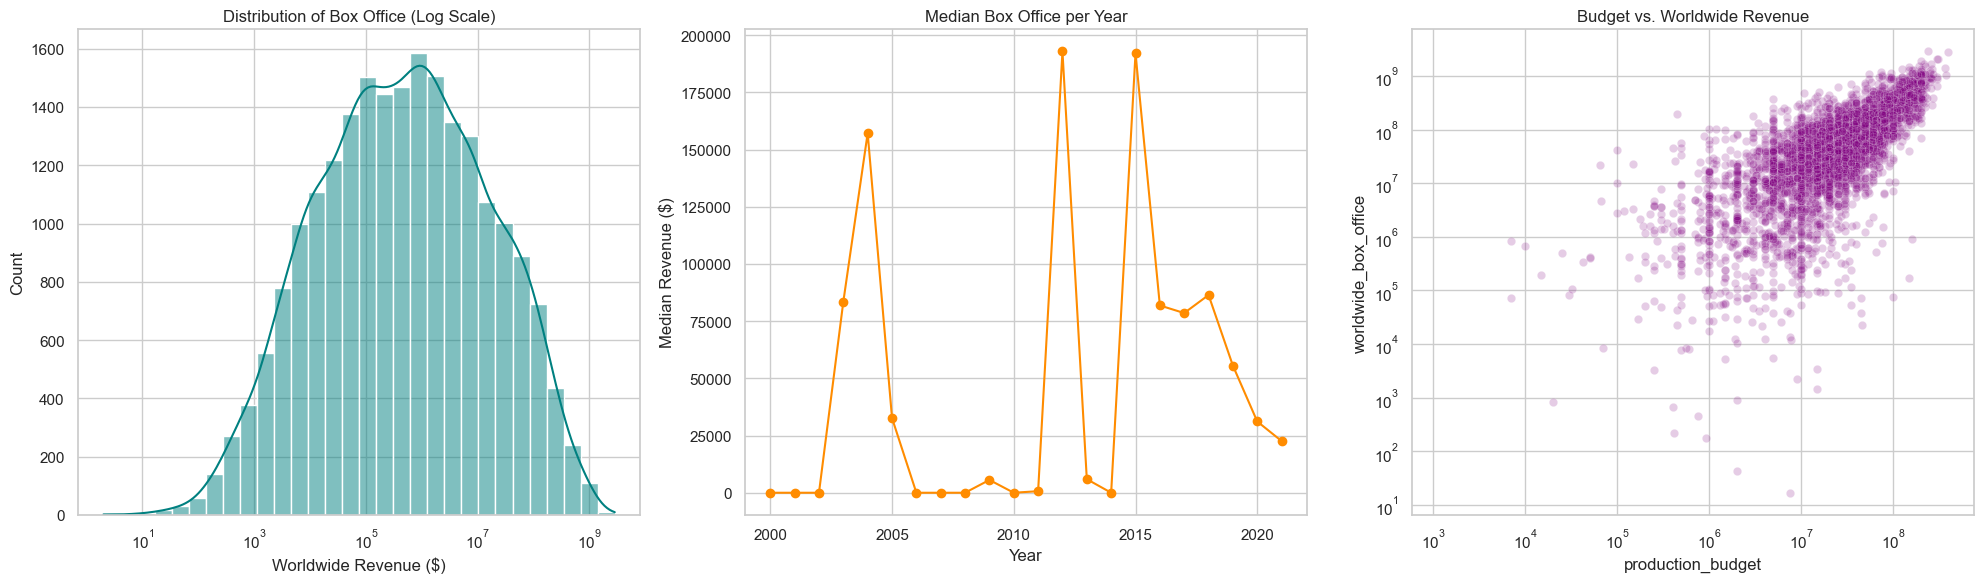

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots in 1 row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Distribution of Worldwide Box Office (Log Scale)
# This shows us the scale of the movies—most are small, few are blockbusters.
sns.histplot(df_sales[df_sales['worldwide_box_office'] > 0]['worldwide_box_office'], 
             bins=30, kde=True, ax=axes[0], log_scale=True, color='teal')
axes[0].set_title('Distribution of Box Office (Log Scale)')
axes[0].set_xlabel('Worldwide Revenue ($)')

# 2. Box Office Trends Over Time
# Shows how the industry has grown from the 30k records.
yearly_revenue = df_sales.groupby('year')['worldwide_box_office'].median()
axes[1].plot(yearly_revenue.index, yearly_revenue.values, marker='o', color='darkorange')
axes[1].set_title('Median Box Office per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Revenue ($) (Worldwide box office)')

# 3. Production Budget vs. Worldwide Box Office
# A scatter plot to see the correlation between spending and earning.
sns.scatterplot(data=df_sales[df_sales['production_budget'] > 0], 
                x='production_budget', y='worldwide_box_office', 
                alpha=0.2, ax=axes[2], color='purple')
axes[2].set_title('Budget vs. Worldwide Revenue')
axes[2].set_xscale('log')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

C:\Users\md-ra\AppData\Local\Temp\ipykernel_24460\3432702688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='viridis')
C:\Users\md-ra\AppData\Local\Temp\ipykernel_24460\3432702688.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=creative_type.values, y=creative_type.index, ax=axes[1], palette='magma')


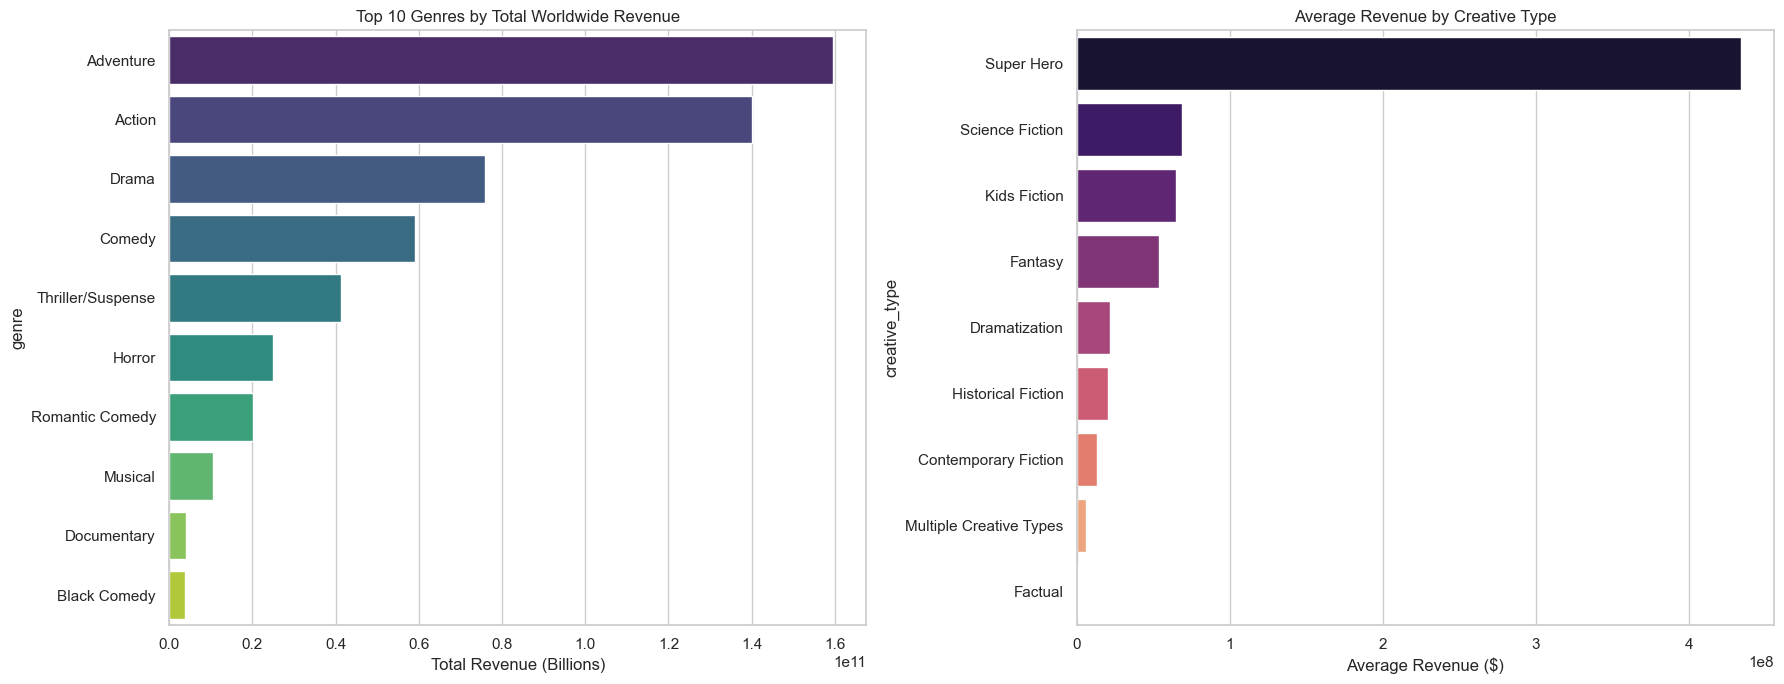

In [20]:
# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Top 10 Genres by Total Revenue
top_genres = df_sales.groupby('genre')['worldwide_box_office'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Genres by Total Worldwide Revenue')
axes[0].set_xlabel('Total Revenue (Billions)')

# 2. Creative Type Success
# Does "Contemporary Fiction" perform better than "Science Fiction" or "Historical"?
creative_type = df_sales.groupby('creative_type')['worldwide_box_office'].mean().sort_values(ascending=False)
sns.barplot(x=creative_type.values, y=creative_type.index, ax=axes[1], palette='magma')
axes[1].set_title('Average Revenue by Creative Type')
axes[1].set_xlabel('Average Revenue ($)')

plt.tight_layout()
plt.show()

# Creating a master table that has all the required features to be used for AI Modeling in a way that answers the business question:

In [15]:
# We will create a master dataframe now in order to move forward:

# 1. Prepare df_sales year
df_sales['year'] = pd.to_numeric(df_sales['year'], errors='coerce')

# 2. Prepare df_meta year (Extracting it from RelDate)
# First, convert RelDate to a proper datetime format
df_meta['RelDate'] = pd.to_datetime(df_meta['RelDate'], errors='coerce')
# Then, extract just the year
df_meta['year'] = df_meta['RelDate'].dt.year

# 3. Merge Meta and Sales using title_clean and our new year column
# We use an 'inner' merge to keep only movies found in both files
df_master = pd.merge(df_meta, df_sales, on=['title_clean', 'year'], how='inner', suffixes=('', '_sales'))

# 4. Add the Review Aggregations (using the Metacritic URL)
df_master = pd.merge(df_master, user_agg, on='url', how='left')
df_master = pd.merge(df_master, expert_agg, on='url', how='left')

# 5. Create the Movie ID
df_master['movie_id'] = range(1, len(df_master) + 1)

print(f"Success! Master Table created with {len(df_master)} movies.")
df_master[['title', 'year', 'movie_id']].head()

Success! Master Table created with 8025 movies.


,title,year,movie_id
0,10 Cloverfield Lane,2016,1
1,10 Years,2012,2
2,100 Bloody Acres,2013,3
3,"10,000 km",2015,4
4,1001 Grams,2015,5
